In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import TimeSeriesSplit
import optuna

In [2]:
df = pd.read_csv("/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/data/processed/Breakfast_feature_2024_2025.csv", parse_dates=["Date"])
holdout_df = pd.read_csv("/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/data/processed/Breakfast_feature_2026.csv", parse_dates=["Date"])

In [3]:
df.shape

(731, 46)

In [4]:
df.head()

,Date,DayOfWeek,DayOfMonth,Month,Is_Start_Of_Month,Is_End_Of_Month,Is_Weekend,Is_Holiday,Is_Vacation,Is_Exam_Period,...,Target_14_Day_Std,Target_14_Day_Max,Target_14_Day_Min,Target_28_Day_Avg,Target_28_Day_Std,Target_28_Day_Max,Target_28_Day_Min,Target_EWMA_7,Target_EWMA_14,Trend_7_vs_28
0,2024-01-01,Monday,1,1,1,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,Tuesday,2,1,1,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.000000,14.000000,NaN
2,2024-01-03,Wednesday,3,1,1,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.750000,13.866667,NaN
3,2024-01-04,Thursday,4,1,1,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.812500,15.484444,NaN
4,2024-01-05,Friday,5,1,1,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.359375,17.019852,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                731 non-null    datetime64[us]
 1   DayOfWeek           731 non-null    str           
 2   DayOfMonth          731 non-null    int64         
 3   Month               731 non-null    int64         
 4   Is_Start_Of_Month   731 non-null    int64         
 5   Is_End_Of_Month     731 non-null    int64         
 6   Is_Weekend          731 non-null    int64         
 7   Is_Holiday          731 non-null    int64         
 8   Is_Vacation         731 non-null    int64         
 9   Is_Exam_Period      731 non-null    int64         
 10  Is_Fest             731 non-null    int64         
 11  Days_Until_Holiday  731 non-null    float64       
 12  DayOfWeek_Sin       731 non-null    float64       
 13  DayOfWeek_Cos       731 non-null    float64       
 14  Month

In [6]:
df_clean = df.dropna().reset_index(drop=True)
print(len(df), ",", len(df_clean))

731 , 601


In [7]:
feature_cols = [c for c in df_clean.columns if c not in ["Date", "Target_Headcount", "Category", "Notes", "DayOfWeek"]]

X = df_clean[feature_cols]
Y = df_clean["Target_Headcount"]

In [8]:
train_mask = df_clean["Date"].dt.year == 2024
validate_mask = df_clean["Date"].dt.year == 2025

X_train, Y_train = X[train_mask], Y[train_mask]
X_validate, Y_validate = X[validate_mask], Y[validate_mask]

print(len(X_train), len(Y_train), "\n", len(X_validate), len(Y_validate))

256 256 
 345 345


In [9]:
print(X_train.shape)
print(X_validate.shape)

print(df_clean.loc[train_mask, "Date"].min(), df_clean.loc[train_mask, "Date"].max())
print(df_clean.loc[validate_mask, "Date"].min(), df_clean.loc[validate_mask, "Date"].max())

(256, 43)
(345, 43)
2024-01-29 00:00:00 2024-12-07 00:00:00
2025-01-21 00:00:00 2025-12-31 00:00:00


In [10]:
print(X_train.iloc[100])

DayOfMonth              8.000000
Month                   5.000000
Is_Start_Of_Month       0.000000
Is_End_Of_Month         0.000000
Is_Weekend              0.000000
Is_Holiday              0.000000
Is_Vacation             0.000000
Is_Exam_Period          1.000000
Is_Fest                 0.000000
Days_Until_Holiday     99.000000
DayOfWeek_Sin           0.974928
DayOfWeek_Cos          -0.222521
Month_Sin               0.500000
Month_Cos              -0.866025
Is_Broke_Weekend        0.000000
Is_Rich_Weekend         0.000000
WeekOfYear             19.000000
DayOfYear             129.000000
Target_1_Days_Ago     103.000000
Target_2_Days_Ago     106.000000
Target_3_Days_Ago      66.000000
Target_7_Days_Ago      85.000000
Target_14_Days_Ago    169.000000
Target_21_Days_Ago    143.000000
Target_3_Day_Avg       91.666667
Target_3_Day_Std       22.278540
Target_3_Day_Max      106.000000
Target_3_Day_Min       66.000000
Target_7_Day_Avg       96.857143
Target_7_Day_Std       15.763128
Target_7_D

In [11]:
check_date = df_clean[df_clean["Date"] == "2024-08-10"]
print(check_date[["Date", "Target_Headcount", "Target_7_Days_Ago"]])

seven_days_before = df_clean[df_clean["Date"] == "2024-08-03"]
print(seven_days_before[["Date", "Target_Headcount"]])

          Date  Target_Headcount  Target_7_Days_Ago
136 2024-08-10              80.0               84.0
          Date  Target_Headcount
129 2024-08-03              84.0


In [12]:
window = df_clean[df_clean["Date"].between("2024-03-09", "2024-03-15")]
print(window[["Date", "Target_Headcount"]])
print("Manual 7-day avg:", window["Target_Headcount"].mean())

print("Target_7_Day_Avg column says:", df_clean[df_clean["Date"] == "2024-03-16"]["Target_7_Day_Avg"].values)

         Date  Target_Headcount
40 2024-03-09              51.0
41 2024-03-10              45.0
42 2024-03-11             130.0
43 2024-03-12             197.0
44 2024-03-13             192.0
45 2024-03-14             160.0
46 2024-03-15             157.0
Manual 7-day avg: 133.14285714285714
Target_7_Day_Avg column says: [133.14285714]


In [13]:
"Target_Headcount" in feature_cols

False

In [14]:
X_train.isna().sum().sum()
X_validate.isna().sum().sum()

np.int64(0)

In [15]:
print(len(feature_cols))
print(feature_cols)

43
['DayOfMonth', 'Month', 'Is_Start_Of_Month', 'Is_End_Of_Month', 'Is_Weekend', 'Is_Holiday', 'Is_Vacation', 'Is_Exam_Period', 'Is_Fest', 'Days_Until_Holiday', 'DayOfWeek_Sin', 'DayOfWeek_Cos', 'Month_Sin', 'Month_Cos', 'Is_Broke_Weekend', 'Is_Rich_Weekend', 'WeekOfYear', 'DayOfYear', 'Target_1_Days_Ago', 'Target_2_Days_Ago', 'Target_3_Days_Ago', 'Target_7_Days_Ago', 'Target_14_Days_Ago', 'Target_21_Days_Ago', 'Target_3_Day_Avg', 'Target_3_Day_Std', 'Target_3_Day_Max', 'Target_3_Day_Min', 'Target_7_Day_Avg', 'Target_7_Day_Std', 'Target_7_Day_Max', 'Target_7_Day_Min', 'Target_14_Day_Avg', 'Target_14_Day_Std', 'Target_14_Day_Max', 'Target_14_Day_Min', 'Target_28_Day_Avg', 'Target_28_Day_Std', 'Target_28_Day_Max', 'Target_28_Day_Min', 'Target_EWMA_7', 'Target_EWMA_14', 'Trend_7_vs_28']


In [16]:
model = RandomForestRegressor(random_state=28)

In [17]:
model.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",28
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [18]:
prediction = model.predict(X_validate)

In [19]:
mae = mean_absolute_error(Y_validate, prediction)
rmse = np.sqrt(mean_squared_error(Y_validate, prediction))

baseline_pred = X_validate["Target_7_Days_Ago"]
actual = Y_validate
mask = baseline_pred.notna() & actual.notna()
baseline_mae = (actual[mask] - baseline_pred[mask]).abs().mean()
baseline_rmse = np.sqrt(mean_squared_error(actual[mask], baseline_pred[mask]))

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Model MAE:", mae)
print("Model RMSE:", rmse)

Baseline MAE: 40.91014492753623
Baseline RMSE: 56.32092308202694
Model MAE: 23.272521739130433
Model RMSE: 30.979137991955774


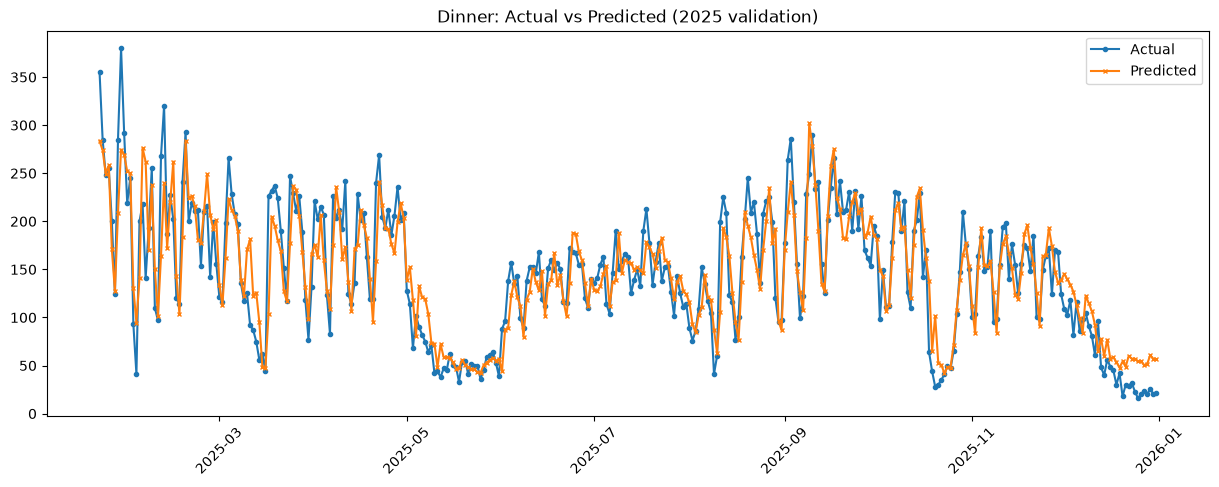

In [20]:
val_dates = df_clean.loc[validate_mask, "Date"]

plt.figure(figsize=(15,5))
plt.plot(val_dates, Y_validate.values, label="Actual", marker='o', markersize=3)
plt.plot(val_dates, prediction, label="Predicted", marker='x', markersize=3)
plt.legend()
plt.title("Dinner: Actual vs Predicted (2025 validation)")
plt.xticks(rotation=45)
plt.show()

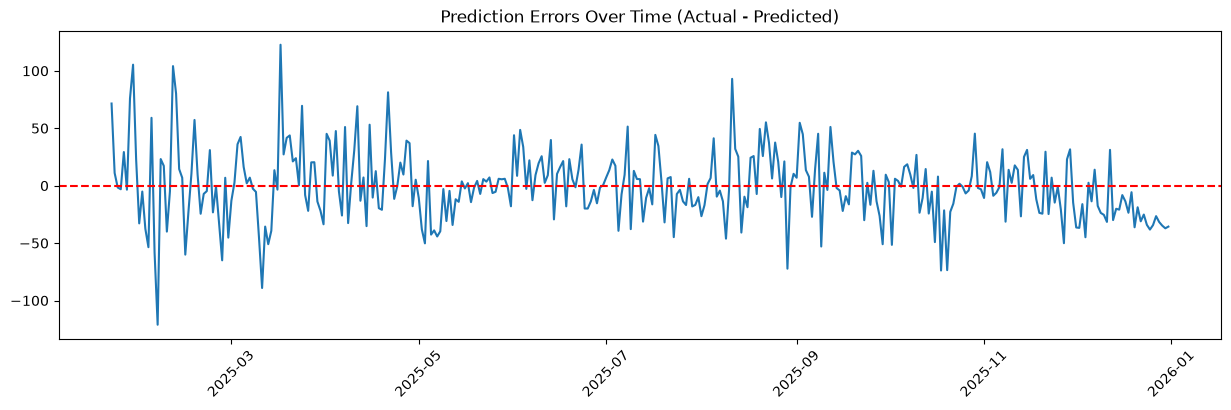

In [21]:
residuals = Y_validate.values - prediction

plt.figure(figsize=(15,4))
plt.plot(val_dates, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Prediction Errors Over Time (Actual - Predicted)")
plt.xticks(rotation=45)
plt.show()

In [22]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(15)

Target_1_Days_Ago     0.467606
Target_7_Days_Ago     0.136345
Days_Until_Holiday    0.039082
DayOfWeek_Sin         0.033662
Target_14_Days_Ago    0.028233
Trend_7_vs_28         0.023045
Target_21_Days_Ago    0.020907
DayOfMonth            0.017767
Target_7_Day_Std      0.017599
Target_3_Day_Max      0.016874
DayOfWeek_Cos         0.016247
Is_Holiday            0.015187
Target_3_Day_Std      0.014797
Target_7_Day_Avg      0.011707
Is_Weekend            0.010786
dtype: float64

In [23]:
df_sorted = df_clean.sort_values("Date").reset_index(drop=True)

fold_windows = [
    ("2024-01-01", "2024-12-31", "2025-01-01", "2025-03-01"),
    ("2024-01-01", "2025-03-01", "2025-03-01", "2025-05-01"),
    ("2024-01-01", "2025-05-01", "2025-05-01", "2025-07-01"),
    ("2024-01-01", "2025-07-01", "2025-07-01", "2025-09-01"),
    ("2024-01-01", "2025-09-01", "2025-09-01", "2025-11-01"),
    ("2024-01-01", "2025-11-01", "2025-11-01", "2025-12-31"),
]
results = []

for name, ModelClass, params in [
    ("RandomForest", RandomForestRegressor, {"random_state":28}),
    ("XGBoost", XGBRegressor, {"random_state": 28}),
    ("LightGBM", LGBMRegressor, {"random_state": 28, "verbose": -1}),
    ("CatBoost", CatBoostRegressor, {"random_state": 28, "verbose": 0}),
]:
    fold_MAEs = []
    fold_RMSEs = []
    
    for train_start, train_end, val_start, val_end in fold_windows:
        
        train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
        val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
        
        model = ModelClass(**params)
        model.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
        pred = model.predict(val_fold[feature_cols])
        fold_MAEs.append(mean_absolute_error(val_fold["Target_Headcount"], pred))
        fold_RMSEs.append(np.sqrt(mean_squared_error(val_fold["Target_Headcount"], pred)))
        
    results.append({
        "Model": name,
        "MAE": np.mean(fold_MAEs),
        "MAE STD": np.std(fold_MAEs),
        "RMSE": np.mean(fold_RMSEs),
        "RMSE STD": np.std(fold_RMSEs),
    })

    print(f"{name}")
    print(f"Average MAE  : {np.mean(fold_MAEs):.2f} ± {np.std(fold_MAEs):.2f}")
    print(f"Average RMSE : {np.mean(fold_RMSEs):.2f} ± {np.std(fold_RMSEs):.2f}")
    print(f"Fold MAEs    : {[round(float(x),1) for x in fold_MAEs]}")
    print(f"Fold RMSEs   : {[round(float(x),1) for x in fold_RMSEs]}")
    print()

RandomForest
Average MAE  : 24.10 ± 6.15
Average RMSE : 31.84 ± 8.45
Fold MAEs    : [35.5, 28.0, 16.6, 22.9, 21.5, 20.0]
Fold RMSEs   : [47.4, 37.9, 23.3, 29.9, 28.5, 24.0]

XGBoost
Average MAE  : 26.54 ± 6.11
Average RMSE : 33.98 ± 7.42
Fold MAEs    : [38.5, 28.8, 18.9, 25.8, 24.3, 23.0]
Fold RMSEs   : [47.9, 38.8, 26.5, 31.3, 32.2, 27.2]

LightGBM
Average MAE  : 25.53 ± 6.00
Average RMSE : 32.34 ± 7.65
Fold MAEs    : [36.4, 30.9, 22.3, 22.0, 21.8, 19.8]
Fold RMSEs   : [45.7, 39.3, 29.3, 27.8, 28.3, 23.6]

CatBoost
Average MAE  : 27.19 ± 7.42
Average RMSE : 34.56 ± 9.75
Fold MAEs    : [42.1, 29.2, 19.4, 21.1, 25.3, 26.0]
Fold RMSEs   : [54.7, 37.5, 26.0, 27.2, 32.4, 29.6]



In [24]:
def objective(trial):
    parameters = {
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 12),  # widened from 8

        "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        
        "random_state": 28,
        "n_jobs": -1,
    }

    fold_maes = []
    for train_start, train_end, val_start, val_end in fold_windows:
        train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
        val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
        model = XGBRegressor(**parameters)
        model.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
        pred = model.predict(val_fold[feature_cols])
        fold_maes.append(mean_absolute_error(val_fold["Target_Headcount"], pred))

    return np.mean(fold_maes)

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=28, multivariate=True, group=True)
)
study.optimize(objective, n_trials=400, show_progress_bar=True)  # bumped from 100

print("\nBest MAE:")
print(f"{study.best_value:.2f}")
print("\nBest Parameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")
print("\nTop 10 Trials:")
display(study.trials_dataframe().sort_values("value").head(10))

/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-07-11 20:49:18,275] A new study created in memory with name: no-name-966e0dc7-ba7c-4f44-81dc-b72411af7383


  0%|          | 0/400 [00:00<?, ?it/s]

[I 2026-07-11 20:49:20,289] Trial 0 finished with value: 26.593631301669134 and parameters: {'learning_rate': 0.09891603549518685, 'n_estimators': 493, 'max_depth': 4, 'min_child_weight': 6, 'gamma': 3.9065410313673805, 'reg_alpha': 0.11065522526191614, 'reg_lambda': 0.005379890467195983, 'subsample': 0.9267564376244264, 'colsample_bytree': 0.9776859463174046}. Best is trial 0 with value: 26.593631301669134.
[I 2026-07-11 20:49:22,248] Trial 1 finished with value: 27.353648981396102 and parameters: {'learning_rate': 0.2812227258994409, 'n_estimators': 235, 'max_depth': 12, 'min_child_weight': 4, 'gamma': 0.1317692425493533, 'reg_alpha': 6.0847308477212225, 'reg_lambda': 4.862945563972716, 'subsample': 0.6469878839059903, 'colsample_bytree': 0.5831368510995121}. Best is trial 0 with value: 26.593631301669134.
[I 2026-07-11 20:49:25,152] Trial 2 finished with value: 24.542880555508997 and parameters: {'learning_rate': 0.02524013197544389, 'n_estimators': 457, 'max_depth': 6, 'min_child_w

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample,state
314,314,23.488330,2026-07-11 21:23:24.827337,2026-07-11 21:23:37.644549,0 days 00:00:12.817212,0.926015,0.841784,0.008922,10,3,709,0.160126,0.026231,0.744129,COMPLETE
296,296,23.504444,2026-07-11 21:20:33.761993,2026-07-11 21:20:48.683704,0 days 00:00:14.921711,0.907952,1.082172,0.014654,10,2,763,0.071943,0.038245,0.750823,COMPLETE
370,370,23.563980,2026-07-11 21:30:25.259237,2026-07-11 21:30:34.124800,0 days 00:00:08.865563,0.887025,0.919723,0.008714,12,4,537,0.525143,0.006258,0.769500,COMPLETE
378,378,23.576336,2026-07-11 21:31:25.545651,2026-07-11 21:31:38.516762,0 days 00:00:12.971111,0.914774,3.907200,0.008966,8,2,770,0.128121,0.001217,0.704924,COMPLETE
397,397,23.580262,2026-07-11 21:33:51.460748,2026-07-11 21:34:00.891590,0 days 00:00:09.430842,0.889042,3.778620,0.005932,9,3,657,0.006404,0.001190,0.727137,COMPLETE
361,361,23.595405,2026-07-11 21:29:10.898977,2026-07-11 21:29:23.272160,0 days 00:00:12.373183,0.974535,4.338761,0.005775,11,3,599,0.036033,0.001752,0.723612,COMPLETE
134,134,23.596690,2026-07-11 20:58:36.340680,2026-07-11 20:58:44.449173,0 days 00:00:08.108493,0.827681,1.927133,0.006878,12,5,671,0.152582,0.023821,0.735329,COMPLETE
272,272,23.599367,2026-07-11 21:16:06.220305,2026-07-11 21:16:18.994367,0 days 00:00:12.774062,0.932819,0.383344,0.005649,9,3,663,0.002569,0.045074,0.732558,COMPLETE
285,285,23.608136,2026-07-11 21:18:35.402515,2026-07-11 21:18:51.388289,0 days 00:00:15.985774,0.871497,0.192424,0.008558,12,4,787,0.099073,0.039518,0.759054,COMPLETE
265,265,23.609533,2026-07-11 21:14:48.638302,2026-07-11 21:14:58.999646,0 days 00:00:10.361344,0.930102,1.731880,0.007735,10,4,570,0.010708,0.050037,0.716329,COMPLETE


In [25]:
def objective_lgbm(trial):
    parameters = {
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),

        "num_leaves": trial.suggest_int("num_leaves", 15, 255),   # widened from 127
        "max_depth": trial.suggest_int("max_depth", 3, 12),        # widened from 10
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 40),

        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": 1,

        "lambda_l1": trial.suggest_float("lambda_l1", 1e-3, 10, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-3, 10, log=True),

        "random_state": 28,
        "verbose": -1,
        "n_jobs": -1,
    }

    fold_maes = []
    for train_start, train_end, val_start, val_end in fold_windows:
        train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
        val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
        model = LGBMRegressor(**parameters)
        model.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
        pred = model.predict(val_fold[feature_cols])
        fold_maes.append(mean_absolute_error(val_fold["Target_Headcount"], pred))

    return np.mean(fold_maes)

study_lgbm = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=28, multivariate=True, group=True)
)
study_lgbm.optimize(objective_lgbm, n_trials=400, show_progress_bar=True)

print("\nBest MAE:")
print(f"{study_lgbm.best_value:.2f}")
print("\nBest Parameters:")
for key, value in study_lgbm.best_params.items():
    print(f"{key}: {value}")
print("\nTop 10 Trials:")
display(study_lgbm.trials_dataframe().sort_values("value").head(10))

/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-07-11 21:34:18,332] A new study created in memory with name: no-name-72a6933f-5b7e-4a15-a019-3db180c17c6b


  0%|          | 0/400 [00:00<?, ?it/s]

[I 2026-07-11 21:34:19,036] Trial 0 finished with value: 28.41669692035777 and parameters: {'learning_rate': 0.09891603549518685, 'n_estimators': 493, 'num_leaves': 45, 'max_depth': 6, 'min_child_samples': 33, 'feature_fraction': 0.7554964908265566, 'bagging_fraction': 0.5913466792079125, 'lambda_l1': 2.5944870122202537, 'lambda_l2': 6.629603735454784}. Best is trial 0 with value: 28.41669692035777.
[I 2026-07-11 21:34:19,738] Trial 1 finished with value: 26.87647112266428 and parameters: {'learning_rate': 0.2812227258994409, 'n_estimators': 235, 'num_leaves': 248, 'max_depth': 5, 'min_child_samples': 5, 'feature_fraction': 0.9730301715484778, 'bagging_fraction': 0.9608624260104734, 'lambda_l1': 0.01499350163142072, 'lambda_l2': 0.004624819726550633}. Best is trial 1 with value: 26.87647112266428.
[I 2026-07-11 21:34:20,497] Trial 2 finished with value: 26.420297865951856 and parameters: {'learning_rate': 0.02524013197544389, 'n_estimators': 457, 'num_leaves': 89, 'max_depth': 7, 'min_

,number,value,datetime_start,datetime_complete,duration,params_bagging_fraction,params_feature_fraction,params_lambda_l1,params_lambda_l2,params_learning_rate,params_max_depth,params_min_child_samples,params_n_estimators,params_num_leaves,state
275,275,23.485167,2026-07-11 21:44:44.384395,2026-07-11 21:44:47.776181,0 days 00:00:03.391786,0.778243,0.935584,0.001866,0.002009,0.008542,11,5,475,166,COMPLETE
218,218,23.486839,2026-07-11 21:42:32.328980,2026-07-11 21:42:35.544889,0 days 00:00:03.215909,0.767963,0.935013,0.007432,0.002503,0.009378,11,5,508,251,COMPLETE
192,192,23.500414,2026-07-11 21:41:32.804479,2026-07-11 21:41:35.797972,0 days 00:00:02.993493,0.740213,0.986411,0.001763,0.002533,0.008722,11,5,472,240,COMPLETE
170,170,23.507982,2026-07-11 21:40:29.229058,2026-07-11 21:40:31.732636,0 days 00:00:02.503578,0.746300,0.938411,0.005626,0.001707,0.007947,12,6,467,182,COMPLETE
333,333,23.564608,2026-07-11 21:46:33.321296,2026-07-11 21:46:39.054997,0 days 00:00:05.733701,0.765095,0.899300,0.005613,0.002881,0.006347,12,5,672,233,COMPLETE
175,175,23.596265,2026-07-11 21:40:44.236655,2026-07-11 21:40:48.219613,0 days 00:00:03.982958,0.734007,0.974394,0.003686,0.002522,0.007179,12,5,548,188,COMPLETE
136,136,23.600805,2026-07-11 21:38:55.862642,2026-07-11 21:38:59.724282,0 days 00:00:03.861640,0.752982,0.915100,0.038424,0.002165,0.008438,10,6,703,163,COMPLETE
353,353,23.602061,2026-07-11 21:47:12.623657,2026-07-11 21:47:16.196287,0 days 00:00:03.572630,0.774040,0.865765,0.010991,0.007724,0.007375,12,5,556,251,COMPLETE
152,152,23.612105,2026-07-11 21:39:42.630607,2026-07-11 21:39:45.515517,0 days 00:00:02.884910,0.749172,0.937019,0.042415,0.003982,0.009257,12,6,543,189,COMPLETE
161,161,23.628634,2026-07-11 21:40:06.771381,2026-07-11 21:40:09.740391,0 days 00:00:02.969010,0.807693,0.927053,0.028118,0.004597,0.010550,12,6,528,181,COMPLETE


In [26]:
def objective_cb(trial):
    parameters = {
        "loss_function": "RMSE",
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "iterations": trial.suggest_int("iterations", 100, 800),
        "depth": trial.suggest_int("depth", 1, 10),  # widened from 3

        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 20),
        "random_strength": trial.suggest_float("random_strength", 0.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 10.0),

        "random_seed": 28,
        "verbose": 0,
    }

    fold_maes = []
    for train_start, train_end, val_start, val_end in fold_windows:
        train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
        val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
        model = CatBoostRegressor(**parameters)
        model.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
        pred = model.predict(val_fold[feature_cols])
        fold_maes.append(mean_absolute_error(val_fold["Target_Headcount"], pred))

    return np.mean(fold_maes)

study_cb = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=28, multivariate=True, group=True)
)
study_cb.optimize(objective_cb, n_trials=400, show_progress_bar=True)

print("\nBest MAE:")
print(f"{study_cb.best_value:.2f}")
print("\nBest Parameters:")
for key, value in study_cb.best_params.items():
    print(f"{key}: {value}")
print("\nTop 10 Trials:")
display(study_cb.trials_dataframe().sort_values("value").head(10))

/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/venv/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-07-11 21:49:07,343] A new study created in memory with name: no-name-f68189ee-89ed-4ea2-86cc-859b339cd3c6


  0%|          | 0/400 [00:00<?, ?it/s]

[I 2026-07-11 21:49:08,712] Trial 0 finished with value: 29.635050385196624 and parameters: {'learning_rate': 0.09891603549518685, 'iterations': 493, 'depth': 2, 'l2_leaf_reg': 8.554255005302226, 'random_strength': 7.813082062734761, 'bagging_temperature': 5.109929816531132}. Best is trial 0 with value: 29.635050385196624.
[I 2026-07-11 21:50:48,563] Trial 1 finished with value: 34.038793721282644 and parameters: {'learning_rate': 0.010563952214732381, 'iterations': 698, 'depth': 10, 'l2_leaf_reg': 19.700055896783798, 'random_strength': 1.9270097382736828, 'bagging_temperature': 9.707951013702171}. Best is trial 0 with value: 29.635050385196624.
[I 2026-07-11 21:51:05,085] Trial 2 finished with value: 48.322478219388586 and parameters: {'learning_rate': 0.013076598023598389, 'iterations': 118, 'depth': 10, 'l2_leaf_reg': 18.51277218839799, 'random_strength': 2.9397576781198054, 'bagging_temperature': 1.6627370219902426}. Best is trial 0 with value: 29.635050385196624.
[I 2026-07-11 21:

,number,value,datetime_start,datetime_complete,duration,params_bagging_temperature,params_depth,params_iterations,params_l2_leaf_reg,params_learning_rate,params_random_strength,state
276,276,23.980954,2026-07-11 22:16:13.518597,2026-07-11 22:16:15.281420,0 days 00:00:01.762823,2.911330,3,403,8.158028,0.024042,0.338711,COMPLETE
302,302,24.284103,2026-07-11 22:18:19.561982,2026-07-11 22:18:20.895265,0 days 00:00:01.333283,3.680103,1,716,2.854069,0.027926,1.410098,COMPLETE
150,150,24.322404,2026-07-11 22:03:31.046710,2026-07-11 22:03:33.077581,0 days 00:00:02.030871,1.459758,3,564,13.975079,0.015773,0.930276,COMPLETE
66,66,24.343036,2026-07-11 21:56:43.562221,2026-07-11 21:56:45.501545,0 days 00:00:01.939324,3.615138,3,546,12.777913,0.022994,0.306940,COMPLETE
277,277,24.349483,2026-07-11 22:16:15.283346,2026-07-11 22:16:16.291003,0 days 00:00:01.007657,3.950637,2,292,5.009246,0.033492,1.658138,COMPLETE
228,228,24.357472,2026-07-11 22:10:49.156094,2026-07-11 22:10:50.172142,0 days 00:00:01.016048,5.251047,1,590,4.995051,0.035255,0.305946,COMPLETE
370,370,24.365202,2026-07-11 22:23:00.581336,2026-07-11 22:23:01.581263,0 days 00:00:00.999927,6.735011,1,556,2.734425,0.032134,0.725171,COMPLETE
244,244,24.370426,2026-07-11 22:12:45.004309,2026-07-11 22:12:46.244377,0 days 00:00:01.240068,5.227822,1,631,7.594690,0.034037,0.602265,COMPLETE
314,314,24.387887,2026-07-11 22:18:37.749186,2026-07-11 22:18:38.801781,0 days 00:00:01.052595,5.381008,1,580,5.421873,0.030549,0.667710,COMPLETE
338,338,24.421536,2026-07-11 22:19:45.059658,2026-07-11 22:19:47.064524,0 days 00:00:02.004866,2.706145,3,422,12.180864,0.017565,0.748707,COMPLETE


In [27]:
xgb_params = {
    **study.best_params,
    "random_state": 28,
    "n_jobs": -1,
}

lgbm_params = {
    **study_lgbm.best_params,
    "bagging_freq": 1,
    "random_state": 28,
    "verbose": -1,
    "n_jobs": -1,
}

cb_params = {
    **study_cb.best_params,
    "loss_function": "RMSE",
    "random_state": 28,
    "verbose": 0,
}

print("XGBoost params:", xgb_params)
print()
print("LightGBM params:", lgbm_params)
print()
print("CatBoost params:", cb_params)
print()

XGBoost params: {'learning_rate': 0.00892238982325371, 'n_estimators': 709, 'max_depth': 10, 'min_child_weight': 3, 'gamma': 0.8417841167820191, 'reg_alpha': 0.16012609044708653, 'reg_lambda': 0.02623062811589908, 'subsample': 0.7441287683127759, 'colsample_bytree': 0.9260152965024393, 'random_state': 28, 'n_jobs': -1}

LightGBM params: {'learning_rate': 0.008542188857290287, 'n_estimators': 475, 'num_leaves': 166, 'max_depth': 11, 'min_child_samples': 5, 'feature_fraction': 0.9355842444762894, 'bagging_fraction': 0.7782433394353736, 'lambda_l1': 0.0018659548595820548, 'lambda_l2': 0.0020085771489686214, 'bagging_freq': 1, 'random_state': 28, 'verbose': -1, 'n_jobs': -1}

CatBoost params: {'learning_rate': 0.02404154961631329, 'iterations': 403, 'depth': 3, 'l2_leaf_reg': 8.15802834631553, 'random_strength': 0.3387111901725409, 'bagging_temperature': 2.9113297089023766, 'loss_function': 'RMSE', 'random_state': 28, 'verbose': 0}



In [28]:
tuned_results = []

for name, ModelClass, params in [
    ("RandomForest", RandomForestRegressor, {"random_state":28}),
    ("XGBoost (tuned)", XGBRegressor, {**xgb_params}),
    ("LightGBM (tuned)", LGBMRegressor, {**lgbm_params}),
    ("CatBoost (tuned)", CatBoostRegressor, {**cb_params}),
]:
    fold_MAEs = []
    fold_RMSEs = []
    
    for train_start, train_end, val_start, val_end in fold_windows:
        
        train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
        val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
        
        model = ModelClass(**params)
        model.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
        pred = model.predict(val_fold[feature_cols])
        fold_MAEs.append(mean_absolute_error(val_fold["Target_Headcount"], pred))
        fold_RMSEs.append(np.sqrt(mean_squared_error(val_fold["Target_Headcount"], pred)))
        
    tuned_results.append({
        "Model": name,
        "MAE": np.mean(fold_MAEs),
        "MAE STD": np.std(fold_MAEs),
        "RMSE": np.mean(fold_RMSEs),
        "RMSE STD": np.std(fold_RMSEs),
    })

    print(f"{name}")
    print(f"Average MAE  : {np.mean(fold_MAEs):.2f} ± {np.std(fold_MAEs):.2f}")
    print(f"Average RMSE : {np.mean(fold_RMSEs):.2f} ± {np.std(fold_RMSEs):.2f}")
    print(f"Fold MAEs    : {[round(float(x),1) for x in fold_MAEs]}")
    print(f"Fold RMSEs   : {[round(float(x),1) for x in fold_RMSEs]}")
    print()

RandomForest
Average MAE  : 24.10 ± 6.15
Average RMSE : 31.84 ± 8.45
Fold MAEs    : [35.5, 28.0, 16.6, 22.9, 21.5, 20.0]
Fold RMSEs   : [47.4, 37.9, 23.3, 29.9, 28.5, 24.0]

XGBoost (tuned)
Average MAE  : 23.49 ± 5.75
Average RMSE : 30.69 ± 8.00
Fold MAEs    : [34.1, 27.4, 16.7, 22.3, 21.4, 19.0]
Fold RMSEs   : [45.6, 36.4, 23.0, 28.2, 27.8, 23.2]

LightGBM (tuned)
Average MAE  : 23.49 ± 5.62
Average RMSE : 30.41 ± 7.39
Fold MAEs    : [34.0, 27.2, 17.6, 22.4, 21.2, 18.5]
Fold RMSEs   : [43.5, 36.8, 24.5, 28.1, 27.0, 22.5]

CatBoost (tuned)
Average MAE  : 23.98 ± 5.57
Average RMSE : 31.31 ± 7.54
Fold MAEs    : [34.5, 27.7, 17.4, 21.2, 21.6, 21.5]
Fold RMSEs   : [45.0, 37.7, 24.4, 27.1, 28.8, 24.9]



In [29]:
ensemble_results = []
fold_enMAEs = []
fold_enRMSEs = []

model1 = XGBRegressor(**xgb_params)
model2 = LGBMRegressor(**lgbm_params)
model3 = CatBoostRegressor(**cb_params)

for train_start, train_end, val_start, val_end in fold_windows:
    train_fold = df_sorted[(df_sorted["Date"] >= train_start) & (df_sorted["Date"] < train_end)]
    val_fold = df_sorted[(df_sorted["Date"] >= val_start) & (df_sorted["Date"] < val_end)]
    model1.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
    model2.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
    model3.fit(train_fold[feature_cols], train_fold["Target_Headcount"])
    pred1 = model1.predict(val_fold[feature_cols])
    pred2 = model2.predict(val_fold[feature_cols])
    pred3 = model3.predict(val_fold[feature_cols])
    ensemble = (pred1 + pred2 + pred3)/3
    fold_enMAEs.append(mean_absolute_error(val_fold["Target_Headcount"], ensemble))
    fold_enRMSEs.append(np.sqrt(mean_squared_error(val_fold["Target_Headcount"], ensemble)))

tuned_results.append({
        "MAE": np.mean(fold_enMAEs),
        "MAE STD": np.std(fold_enMAEs),
        "RMSE": np.mean(fold_enRMSEs),
        "RMSE STD": np.std(fold_enRMSEs),
    })

print(f"Average MAE  : {np.mean(fold_enMAEs):.2f} ± {np.std(fold_enMAEs):.2f}")
print(f"Average RMSE : {np.mean(fold_enRMSEs):.2f} ± {np.std(fold_enRMSEs):.2f}")
print(f"Fold MAEs    : {[round(float(x),1) for x in fold_enMAEs]}")
print(f"Fold RMSEs   : {[round(float(x),1) for x in fold_enRMSEs]}")

Average MAE  : 23.34 ± 5.67
Average RMSE : 30.36 ± 7.61
Fold MAEs    : [34.0, 27.1, 17.0, 21.6, 20.9, 19.4]
Fold RMSEs   : [44.3, 36.5, 23.5, 27.5, 27.3, 23.2]


In [30]:
train_full = df_sorted[df_sorted["Date"] < "2026-01-01"]
test_janfeb26 = holdout_df

print(f"Train: {train_full['Date'].min()} to {train_full['Date'].max()}, n={len(train_full)}")
print(f"Test:  {test_janfeb26['Date'].min()} to {test_janfeb26['Date'].max()}, n={len(test_janfeb26)}")

xgb_final = XGBRegressor(**xgb_params)
lgbm_final = LGBMRegressor(**lgbm_params)
cb_final = CatBoostRegressor(**cb_params)

for model in [xgb_final, lgbm_final, cb_final]:
    model.fit(train_full[feature_cols], train_full["Target_Headcount"])

pred_xgb = xgb_final.predict(test_janfeb26[feature_cols])
pred_lgbm = lgbm_final.predict(test_janfeb26[feature_cols])
pred_cb = cb_final.predict(test_janfeb26[feature_cols])
pred_ensemble = (pred_xgb + pred_lgbm + pred_cb) / 3

actual = test_janfeb26["Target_Headcount"].values

print()
for name, pred in [("XGBoost", pred_xgb), ("LightGBM", pred_lgbm), ("CatBoost", pred_cb), ("Ensemble", pred_ensemble)]:
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    print(f"{name:10s} MAE: {mae:.2f}  RMSE: {rmse:.2f}")

baseline_pred = test_janfeb26["Target_7_Days_Ago"].values
baseline_mae = mean_absolute_error(actual, baseline_pred)
print(f"\n{'Baseline (7d ago)':10s} MAE: {baseline_mae:.2f}")

Train: 2024-01-29 00:00:00 to 2025-12-31 00:00:00, n=601
Test:  2026-01-01 00:00:00 to 2026-05-31 00:00:00, n=151

XGBoost    MAE: 20.56  RMSE: 27.49
LightGBM   MAE: 20.55  RMSE: 27.62
CatBoost   MAE: 22.21  RMSE: 28.04
Ensemble   MAE: 20.66  RMSE: 27.09

Baseline (7d ago) MAE: 38.09


In [31]:
import json
with open("/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/models/V1/breakfast/best_params.json", "w") as f:
    json.dump({"xgboost": xgb_params, "lightgbm": lgbm_params, "catboost": cb_params}, f, indent=2)

In [32]:
import joblib
joblib.dump(xgb_final, "/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/models/V1/breakfast/breakfast_xgb_v1.joblib")
joblib.dump(lgbm_final, "/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/models/V1/breakfast/breakfast_lgbm_v1.joblib")
joblib.dump(cb_final, "/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/models/V1/breakfast/breakfast_cb_v1.joblib")

['/home/grenzz/funnnn/ml/Mess-Meal-Forecasting/models/V1/breakfast/breakfast_cb_v1.joblib']